# 3. Model Comparison

Benchmark **YOLO variants** on the test split (auto-labelled by notebook 2) and choose the best pretrained model.

| Group | Models |
|---|---|
| YOLO (Ultralytics) | `yolov8n` · `yolov8s` · `yolo11n` · `yolo11s` · `yolo11m` |

**Scoring** (composite): `0.60 × F1 + 0.25 × Speed + 0.15 × IoU`

The winner is written to `person_detector/best_model_choice.json` for notebook 4.


In [22]:
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for pkg in ['ultralytics', 'opencv-python', 'pandas', 'matplotlib', 'tqdm']:
    install(pkg)
print('Dependencies ready.')


Dependencies ready.


In [23]:
import cv2, json, time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from ultralytics import YOLO

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT      = Path('..').resolve()
PD_DIR    = ROOT / 'person_detector'
DS_DIR    = PD_DIR / 'data' / 'dataset'
TEST_IMG  = DS_DIR / 'test' / 'images'
TEST_LBL  = DS_DIR / 'test' / 'labels'

CONF      = 0.7
PERSON    = 0        # YOLO class 0 = closest_person
IOU_THOLD = 0.6

YOLO_MODELS = ['yolov8n.pt', 'yolov8s.pt', 'yolo11n.pt', 'yolo11s.pt', 'yolo11m.pt']

images = sorted(TEST_IMG.glob('*.jpg')) + sorted(TEST_IMG.glob('*.png'))
print(f'Test images : {len(images)}')
if len(images) == 0:
    print('[WARN] No test images found — run notebook 2 first.')


Test images : 182


## 3.1 Shared Helpers

In [24]:
def read_labels(label_path: Path, img_w: int, img_h: int):
    """Parse YOLO-format label file → list of [x1,y1,x2,y2] in pixels."""
    if not label_path.exists(): return []
    boxes = []
    for line in label_path.read_text().strip().split('\n'):
        parts = line.split()
        if len(parts) < 5: continue
        cls = int(parts[0])
        cx, cy, bw, bh = map(float, parts[1:5])
        x1 = (cx - bw/2) * img_w; y1 = (cy - bh/2) * img_h
        x2 = (cx + bw/2) * img_w; y2 = (cy + bh/2) * img_h
        boxes.append([x1, y1, x2, y2])
    return boxes


def iou(a, b):
    ix1 = max(a[0],b[0]); iy1 = max(a[1],b[1])
    ix2 = min(a[2],b[2]); iy2 = min(a[3],b[3])
    inter = max(0, ix2-ix1) * max(0, iy2-iy1)
    union = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter/union if union > 0 else 0.0


def match_closest(preds, gts, thold=IOU_THOLD):
    """
    For closest-person detection: return (tp, fp, fn, best_iou).
    We only care about the single best-scoring pred vs first GT box.
    """
    if not preds and not gts: return 0, 0, 0, 1.0   # no person, correct
    if not preds and gts:     return 0, 0, 1, 0.0
    if preds and not gts:     return 0, 1, 0, 0.0

    gt = gts[0]   # label file has exactly one box (closest person)
    areas = [(p[2]-p[0])*(p[3]-p[1]) for p in preds]
    pred  = preds[int(np.argmax(areas))]   # closest predicted
    ov = iou(pred, gt)
    if ov >= thold:
        return 1, 0, 0, ov
    return 0, 1, 0, ov


def score_summary(name, lat, tp, fp, fn, ious):
    prec  = tp/(tp+fp) if (tp+fp)>0 else 0
    rec   = tp/(tp+fn) if (tp+fn)>0 else 0
    f1    = 2*prec*rec/(prec+rec+1e-9)
    avg_i = float(np.mean(ious)) if ious else 0
    avg_m = float(np.mean(lat))
    return {'name': name, 'precision': round(prec,3), 'recall': round(rec,3),
            'f1': round(f1,3), 'avg_iou': round(avg_i,3),
            'avg_ms': round(avg_m,1)}


print('Helpers ready.')

Helpers ready.


## 3.2 YOLO Evaluator

In [25]:
EVAL_CACHE_DIR = PD_DIR / 'eval_cache'
EVAL_CACHE_DIR.mkdir(parents=True, exist_ok=True)

def _cache_path(model_name: str) -> Path:
    return EVAL_CACHE_DIR / f"{model_name.replace('.pt', '')}.json"

def _load_cache(model_name: str) -> dict | None:
    p = _cache_path(model_name)
    if p.exists():
        with open(p) as f:
            return json.load(f)
    return None

def _save_cache(model_name: str, result: dict) -> None:
    with open(_cache_path(model_name), 'w') as f:
        json.dump(result, f, indent=2)

def eval_yolo(model_name: str, images: list, label_dir: Path) -> dict:
    cached = _load_cache(model_name)
    if cached is not None:
        print(f'  [cache] {model_name} — loaded from {_cache_path(model_name).name}')
        return cached

    mdl = YOLO(model_name)
    tp = fp = fn = 0
    lat = []; ious = []
    for img_path in tqdm(images, desc=model_name, leave=False):
        frame = cv2.imread(str(img_path))
        h, w  = frame.shape[:2]
        gts   = read_labels(label_dir / (img_path.stem + '.txt'), w, h)

        t0  = time.perf_counter()
        res = mdl.predict(frame, classes=[PERSON], conf=CONF, verbose=False)[0]
        lat.append((time.perf_counter() - t0) * 1000)

        preds = res.boxes.xyxy.tolist() if (res.boxes is not None and len(res.boxes) > 0) else []
        t, f_pos, f_neg, ov = match_closest(preds, gts)
        tp += t; fp += f_pos; fn += f_neg
        if ov > 0: ious.append(ov)

    result = score_summary(model_name.replace('.pt', ''), lat, tp, fp, fn, ious)
    _save_cache(model_name, result)
    return result


yolo_results = []
for m in YOLO_MODELS:
    print(f'Evaluating {m} ...')
    yolo_results.append(eval_yolo(m, images, TEST_LBL))

yolo_df = pd.DataFrame(yolo_results)
print('\n=== YOLO Results ===')
print(yolo_df.to_string(index=False))


Evaluating yolov8n.pt ...


Evaluating yolov8s.pt ...


Evaluating yolo11n.pt ...


Evaluating yolo11s.pt ...


Evaluating yolo11m.pt ...



=== YOLO Results ===
   name  precision  recall    f1  avg_iou  avg_ms
yolov8n      0.977   0.715 0.826    0.934    43.9
yolov8s      0.987   0.872 0.926    0.947    83.2
yolo11n      0.992   0.680 0.807    0.959    36.9
yolo11s      0.976   0.933 0.954    0.955    71.6
yolo11m      1.000   1.000 1.000    1.000   145.4


In [30]:
all_df = yolo_df.copy()

# Normalize 0-1 (higher = better for all three metrics)
all_df['f1_norm']  = (all_df['f1'] - all_df['f1'].min()) / (all_df['f1'].max() - all_df['f1'].min() + 1e-9)
all_df['spd_norm'] = 1 - (all_df['avg_ms'] - all_df['avg_ms'].min()) / (all_df['avg_ms'].max() - all_df['avg_ms'].min() + 1e-9)
all_df['iou_norm'] = (all_df['avg_iou'] - all_df['avg_iou'].min()) / (all_df['avg_iou'].max() - all_df['avg_iou'].min() + 1e-9)

all_df['score'] = (0.60 * all_df['f1_norm'] +
                   0.25 * all_df['spd_norm'] +
                   0.15 * all_df['iou_norm']).round(4)

ranking = all_df.sort_values('score', ascending=False).reset_index(drop=True)

print('=== Ranking (0.60·F1 + 0.25·Speed + 0.15·IoU) ===')
print(ranking[['name', 'f1', 'avg_iou', 'avg_ms', 'score']].to_string(index=True))

best = ranking.iloc[0]
print(f'\n>>> Best model: {best["name"]}  (score={best["score"]})')


=== Ranking (0.60·F1 + 0.25·Speed + 0.15·IoU) ===
      name     f1  avg_iou  avg_ms   score
0  yolo11m  1.000    1.000   145.4  0.7500
1  yolo11s  0.954    0.955    71.6  0.6748
2  yolov8s  0.926    0.947    83.2  0.5428
3  yolo11n  0.807    0.959    36.9  0.3068
4  yolov8n  0.826    0.934    43.9  0.2929

>>> Best model: yolo11m  (score=0.75)


## 3.5 Visualise — Bar Chart + Radar

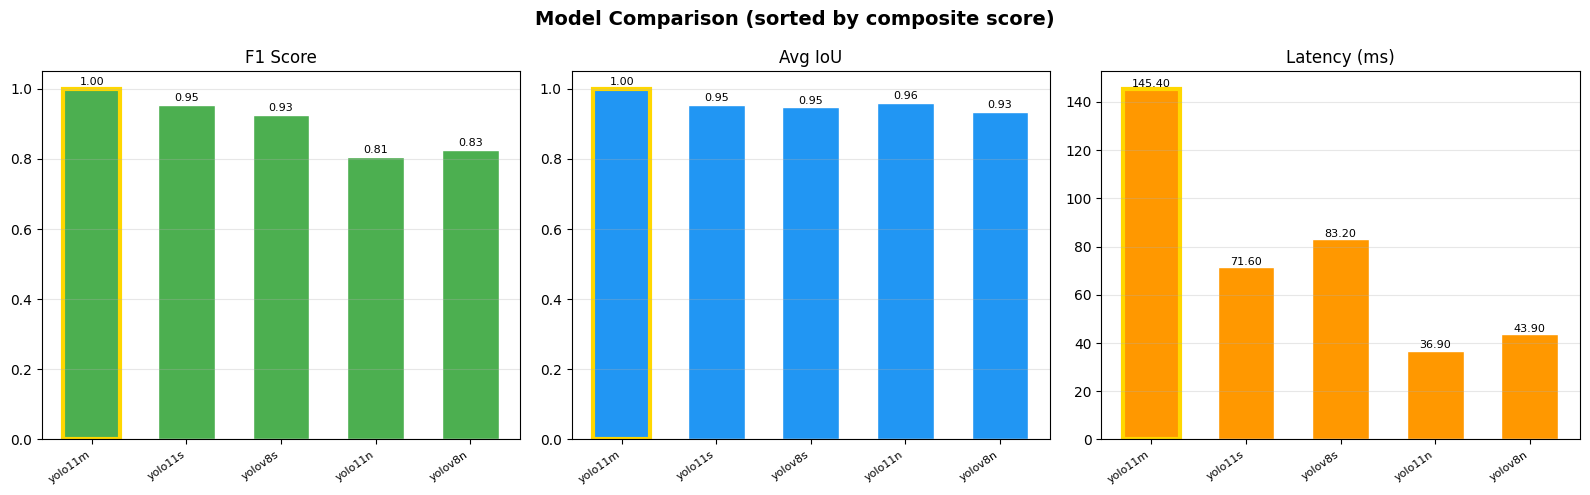

Winner highlighted with gold border: yolo11m


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Comparison (sorted by composite score)', fontsize=14, fontweight='bold')

names = ranking['name'].tolist()
x     = np.arange(len(names))
best_idx = 0   # ranking is sorted descending → winner is always index 0


def bar(ax, values, title, color):
    bars = ax.bar(x, values, color=color, edgecolor='white', width=0.6)
    # Highlight winner with gold border
    bars[best_idx].set_edgecolor('#FFD700')
    bars[best_idx].set_linewidth(3)
    for b, v in zip(bars, values):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.005,
                f'{v:.2f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=35, ha='right', fontsize=8)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)


bar(axes[0], ranking['f1'].tolist(),      'F1 Score',      '#4CAF50')
bar(axes[1], ranking['avg_iou'].tolist(), 'Avg IoU',       '#2196F3')
bar(axes[2], ranking['avg_ms'].tolist(),  'Latency (ms)',  '#FF9800')

plt.tight_layout()
plt.savefig(str(PD_DIR / 'comparison_bars.png'), dpi=120, bbox_inches='tight')
plt.show()
print(f'Winner highlighted with gold border: {names[best_idx]}')


## 3.6 Qualitative Comparison — Sample Frames

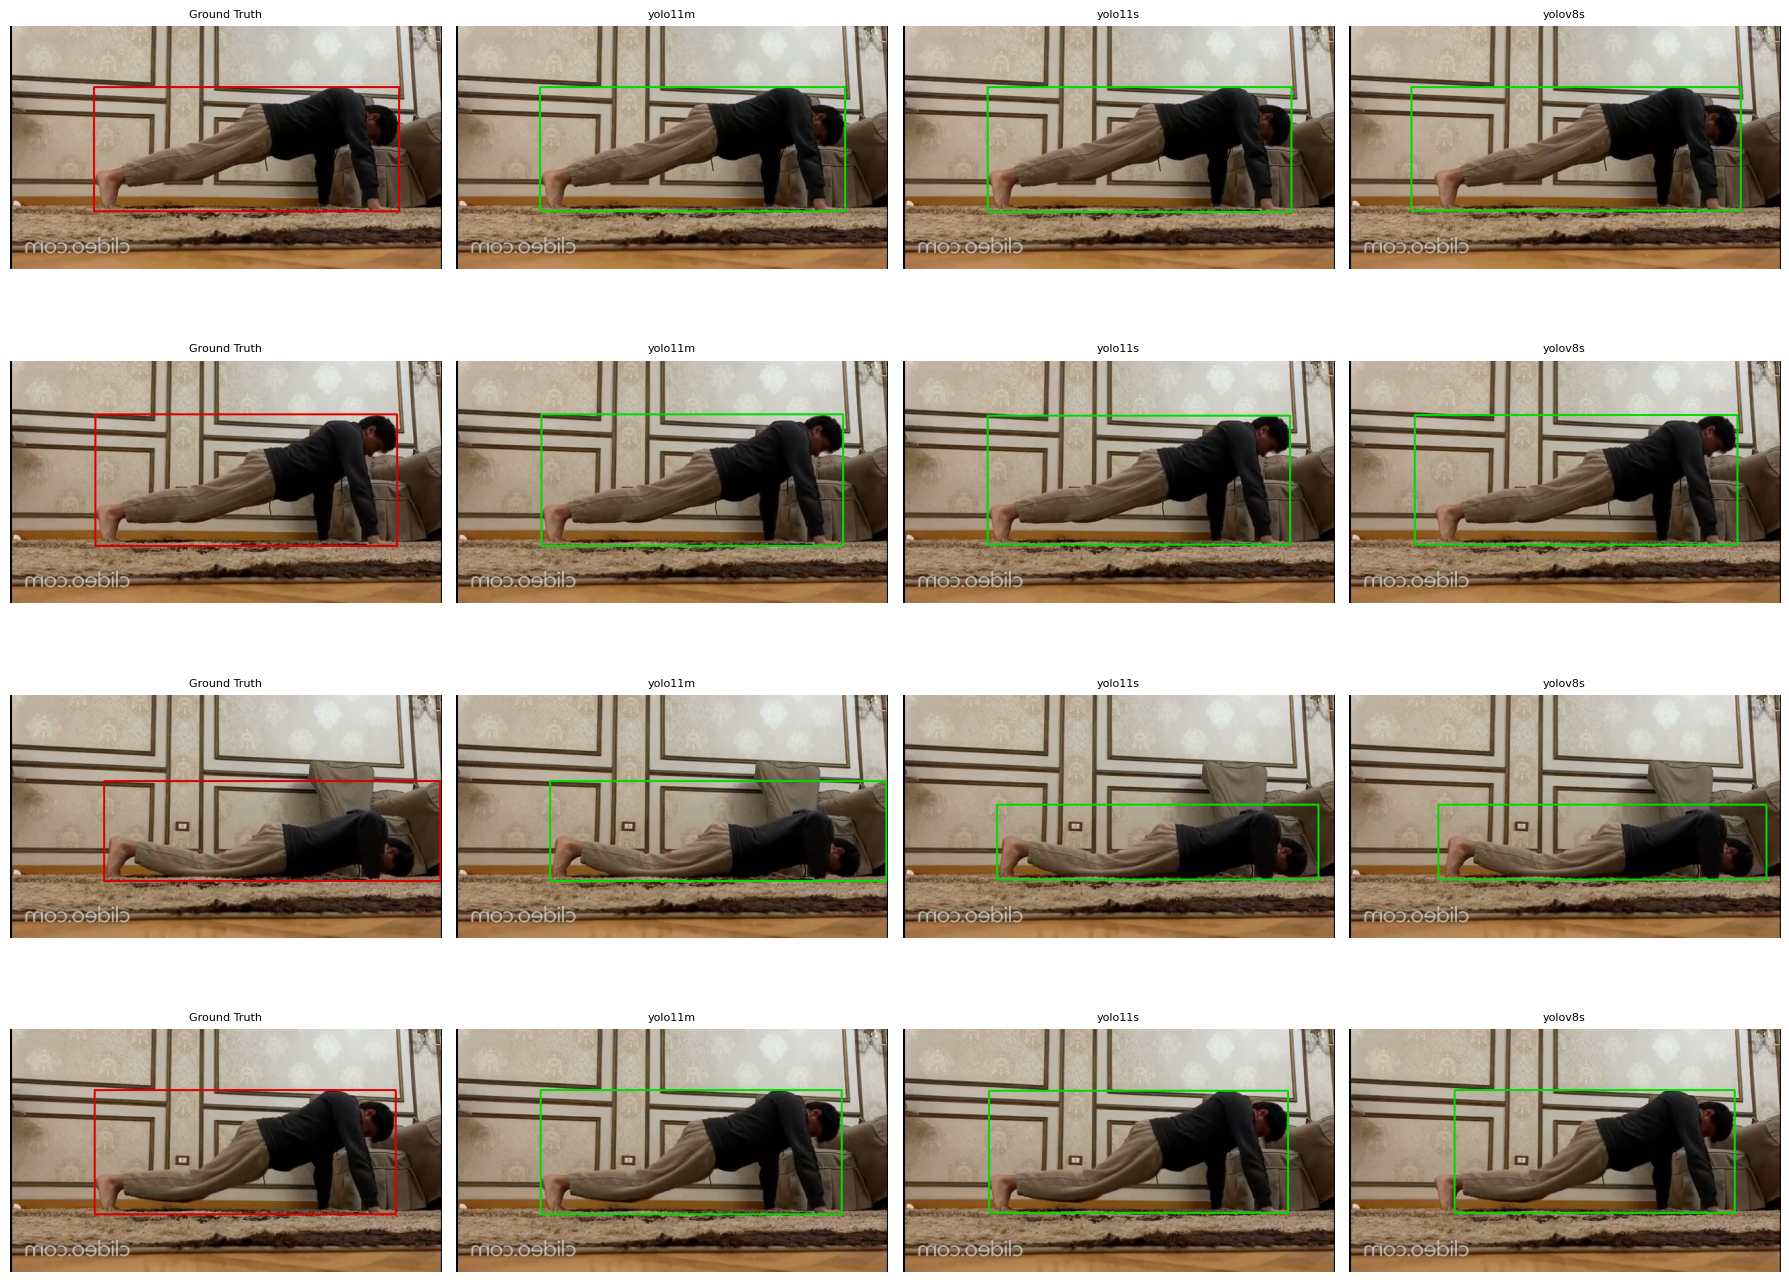

In [32]:
if len(images) == 0:
    print('No test images to display.')
else:
    sample_imgs = images[:4]
    top3        = ranking['name'].tolist()[:3]   # derived from ranking, not hardcoded

    # Pre-load all YOLO models once — avoids reloading per image
    model_cache = {n: YOLO(n + '.pt') for n in top3}

    cols = len(top3) + 1   # GT + one per model
    fig, axes = plt.subplots(len(sample_imgs), cols,
                             figsize=(4.5 * cols, 3.5 * len(sample_imgs)))
    if len(sample_imgs) == 1:
        axes = [axes]

    def draw_pred(img_bgr, pred_boxes):
        vis = img_bgr.copy()
        if pred_boxes:
            areas = [(b[2]-b[0])*(b[3]-b[1]) for b in pred_boxes]
            ci    = int(np.argmax(areas))
            for i, b in enumerate(pred_boxes):
                x1, y1, x2, y2 = map(int, b)
                c = (0, 220, 0) if i == ci else (200, 100, 50)
                cv2.rectangle(vis, (x1, y1), (x2, y2), c, 2)
        return cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)

    for r, img_path in enumerate(sample_imgs):
        img = cv2.imread(str(img_path))
        h, w = img.shape[:2]
        gts  = read_labels(TEST_LBL / (img_path.stem + '.txt'), w, h)

        # GT column
        vis_gt = img.copy()
        for g in gts:
            cv2.rectangle(vis_gt, tuple(map(int, g[:2])), tuple(map(int, g[2:])), (0, 0, 220), 2)
        axes[r][0].imshow(cv2.cvtColor(vis_gt, cv2.COLOR_BGR2RGB))
        axes[r][0].set_title('Ground Truth', fontsize=8)
        axes[r][0].axis('off')

        # Model columns
        for c, name in enumerate(top3):
            res   = model_cache[name].predict(img, classes=[PERSON],
                                              conf=CONF, verbose=False)[0]
            preds = res.boxes.xyxy.tolist() if (res.boxes and len(res.boxes) > 0) else []
            axes[r][c+1].imshow(draw_pred(img, preds))
            axes[r][c+1].set_title(name, fontsize=8)
            axes[r][c+1].axis('off')

    plt.tight_layout()
    plt.show()


## 3.7 Save Best Model Choice

In [33]:
best_row = ranking.iloc[0]
name     = best_row['name']   # e.g. 'yolo11n'

backend  = 'YOLO'
model_id = name + '.pt'       # e.g. 'yolo11n.pt'

# Build structured top3 so notebook 4 constructs EVAL_MODELS without hardcoding
top3_models = [
    {'name': row['name'], 'backend': 'YOLO', 'model_id': row['name'] + '.pt'}
    for _, row in ranking.head(3).iterrows()
]

choice = {
    'model_id'    : model_id,
    'backend'     : backend,
    'score'       : float(best_row['score']),
    'f1'          : float(best_row['f1']),
    'avg_iou'     : float(best_row['avg_iou']),
    'avg_ms'      : float(best_row['avg_ms']),
    'top3_models' : top3_models,   # [{name, backend, model_id}, ...]
}

choice_path = PD_DIR / 'best_model_choice.json'
choice_path.write_text(json.dumps(choice, indent=2))

print(f'Saved → {choice_path}')
print(json.dumps(choice, indent=2))
print('\nNext step → notebook 4 (4.model_evaluation.ipynb)')


Saved → /Users/haleytran/Downloads/pushup_judge/person_detector/best_model_choice.json
{
  "model_id": "yolo11m.pt",
  "backend": "YOLO",
  "score": 0.75,
  "f1": 1.0,
  "avg_iou": 1.0,
  "avg_ms": 145.4,
  "top3_models": [
    {
      "name": "yolo11m",
      "backend": "YOLO",
      "model_id": "yolo11m.pt"
    },
    {
      "name": "yolo11s",
      "backend": "YOLO",
      "model_id": "yolo11s.pt"
    },
    {
      "name": "yolov8s",
      "backend": "YOLO",
      "model_id": "yolov8s.pt"
    }
  ]
}

Next step → notebook 4 (4.model_evaluation.ipynb)
